In [1]:
import pandas as pd
import numpy as np


In [2]:
train=pd.read_csv('C:/Users/hp/Desktop/ntg/Customer chur prediction/Dataset/customer_churn_dataset-training-master.csv')

In [3]:
train.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [4]:
test=pd.read_csv(r'C:\Users\hp\Desktop\ntg\Customer chur prediction\Dataset\customer_churn_dataset-testing-master.csv')
test.head(5)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


In [5]:
train.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

# EDA

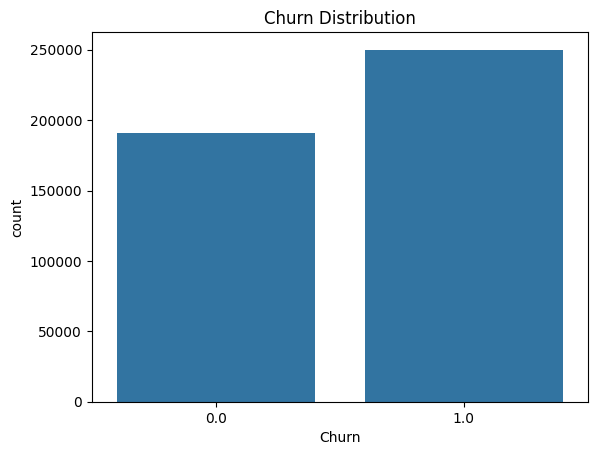

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x='Churn',data=train)
plt.title('Churn Distribution')

plt.show()

<Axes: xlabel='Contract Length', ylabel='count'>

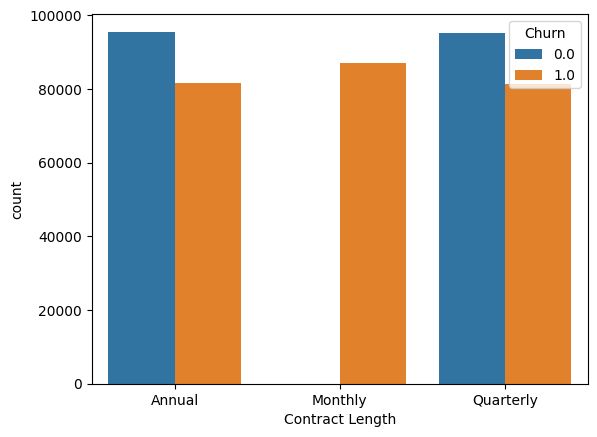

In [7]:
sns.countplot(x='Contract Length', hue='Churn', data=train)

<Axes: xlabel='Tenure', ylabel='Density'>

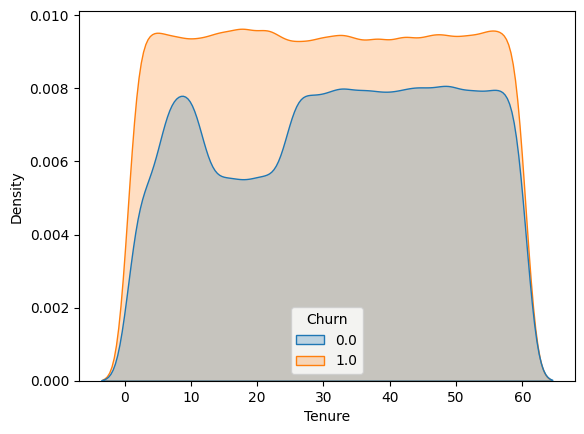

In [8]:
sns.kdeplot(data=train, x='Tenure', hue='Churn', fill=True)


In [9]:
train.head(3)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0


<Axes: xlabel='Total Spend', ylabel='Density'>

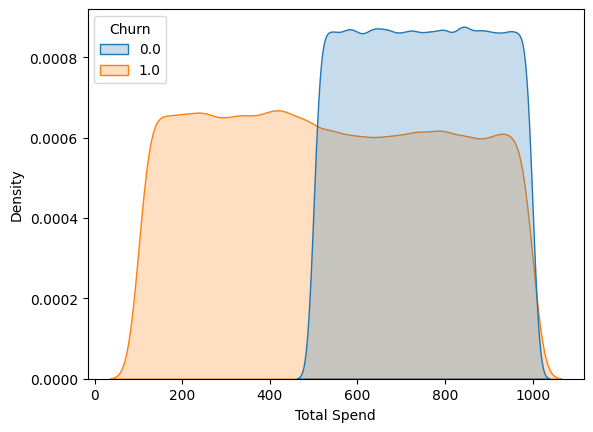

In [10]:
sns.kdeplot(data=train, x='Total Spend', hue='Churn', fill=True)


In [11]:
train.isnull().sum()

CustomerID           1
Age                  1
Gender               1
Tenure               1
Usage Frequency      1
Support Calls        1
Payment Delay        1
Subscription Type    1
Contract Length      1
Total Spend          1
Last Interaction     1
Churn                1
dtype: int64

In [12]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
# Numeric columns
numeric_cols = ['Age', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Total Spend', 'Last Interaction','Churn']
for col in numeric_cols:
    median_val = train[col].median()
    train[col] = train[col].fillna(median_val)
    test[col] = test[col].fillna(median_val)

# Categorical columns (excluding Churn)
cat_cols = ['Gender', 'Subscription Type', 'Contract Length']
for col in cat_cols:
    mode_val = train[col].mode()[0]
    train[col] = train[col].fillna(mode_val)
    test[col] = test[col].fillna(mode_val)
train['Gender']=le.fit_transform(train['Gender'])
test['Gender']=le.transform(test['Gender'])

In [13]:
## Ordinal 
from sklearn.preprocessing import OrdinalEncoder
ord=OrdinalEncoder()
ord_col=['Subscription Type'	,'Contract Length']
for col in ord_col:
    train[ord_col]=ord.fit_transform(train[ord_col])
    test[ord_col]=ord.transform(test[ord_col])




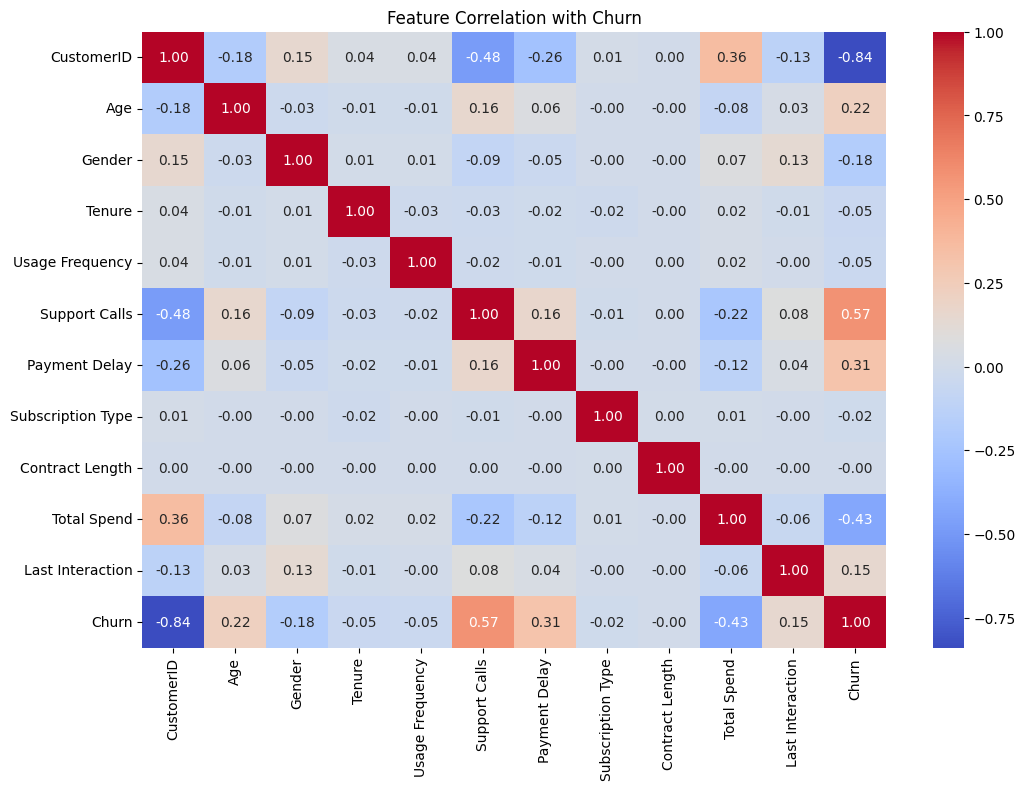

In [14]:
plt.figure(figsize=(12, 8))
# Ensure you only use numeric columns
sns.heatmap(train.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation with Churn')
plt.show()

In [15]:
train.head(2)

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,0,39.0,14.0,5.0,18.0,2.0,0.0,932.0,17.0,1.0
1,3.0,65.0,0,49.0,1.0,10.0,8.0,0.0,1.0,557.0,6.0,1.0


In [16]:
train=train.drop('CustomerID',axis=1)
test=test.drop('CustomerID',axis=1)

In [17]:
x_train=train.iloc[:,:-1]
y_train=train.iloc[:,-1]
x_test=test.iloc[:,:-1]
y_test=test.iloc[:,-1]


In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [18]:
y_train.isnull().sum()

0

In [41]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight='balanced')
lr.fit(x_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [42]:
lr_predict = lr.predict(x_test_scaled)

In [21]:
from sklearn.metrics import accuracy_score


In [22]:
accuracy=accuracy_score(y_test,lr_predict)

In [43]:
print(accuracy)

0.5874576692453475


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(class_weight='balanced')
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20],
    'criterion': ['gini']
}
Gs = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, n_jobs=-1)
Gs.fit(x_train, y_train)

In [37]:
rf_predict = Gs.best_estimator_.predict(x_test)

In [28]:
accuray_rf=accuracy_score(y_test,rf_predict)

In [38]:
accuray_rf

0.5035107341473266

In [30]:
from xgboost import XGBClassifier

In [31]:
xgb = XGBClassifier()
xgb.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
xgb_predict = xgb.predict(x_test)

In [33]:
xgb_accuracy = accuracy_score(y_test, xgb_predict)
print(xgb_accuracy)

0.5034019945940907


In [34]:
print(y_train.value_counts())

Churn
1.0    250000
0.0    190833
Name: count, dtype: int64
